Dataset Loaded!

   sno  Age     Sex  Job Housing Saving accounts Checking account  \
0    0   67    male    2     own             NaN           little   
1    1   22  female    2     own          little         moderate   
2    2   49    male    1     own          little              NaN   
3    3   45    male    2    free          little           little   
4    4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  

Columns:
 Index(['sno', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1

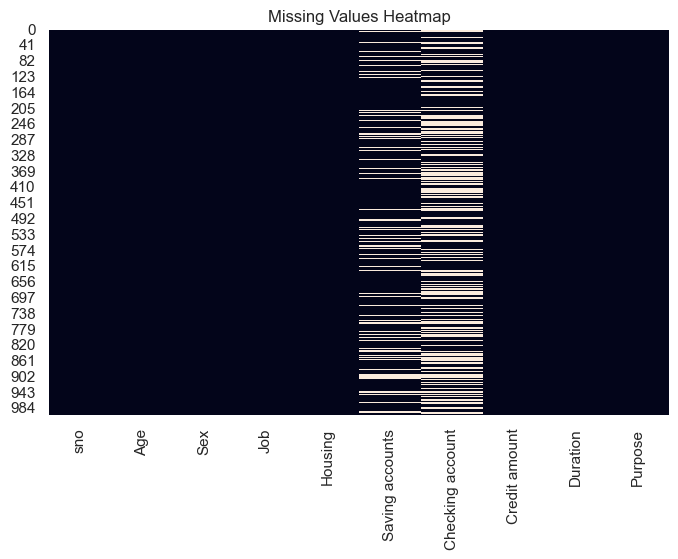

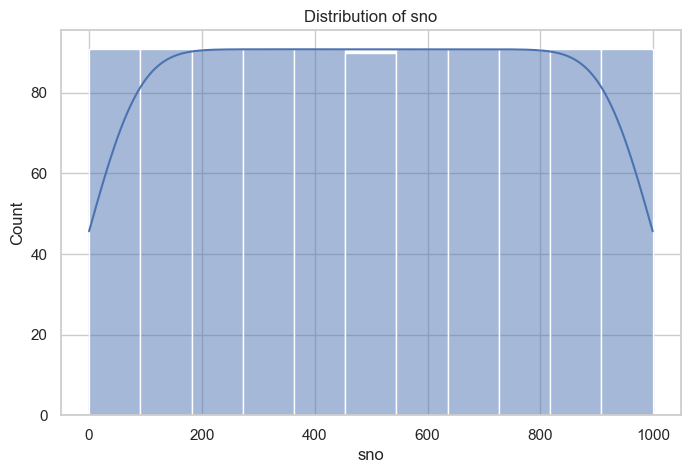

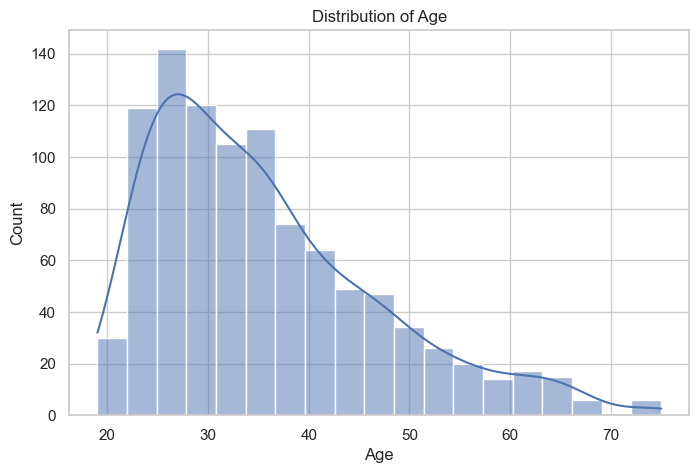

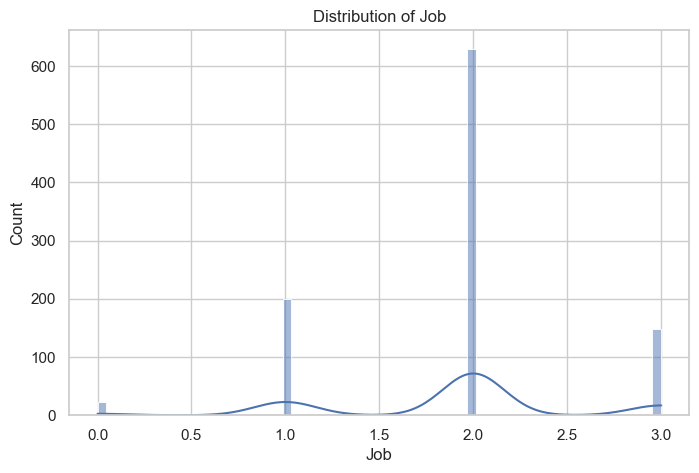

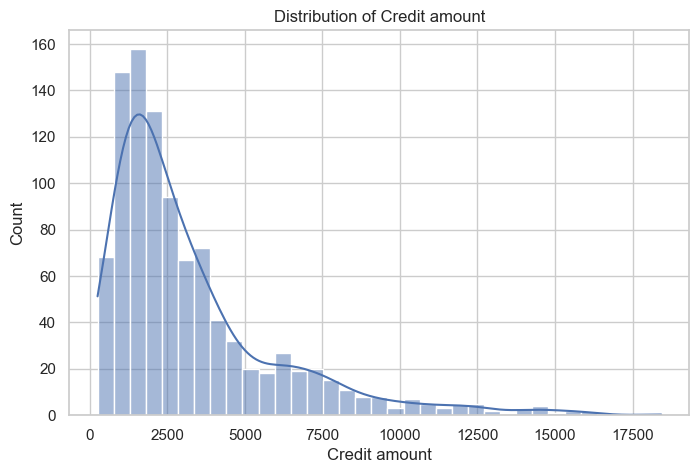

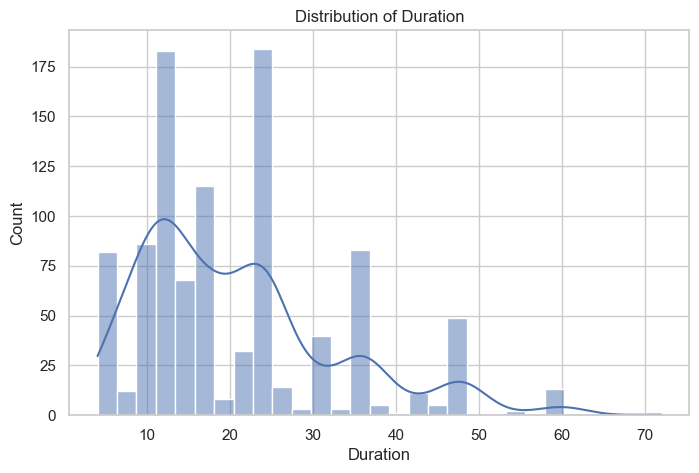

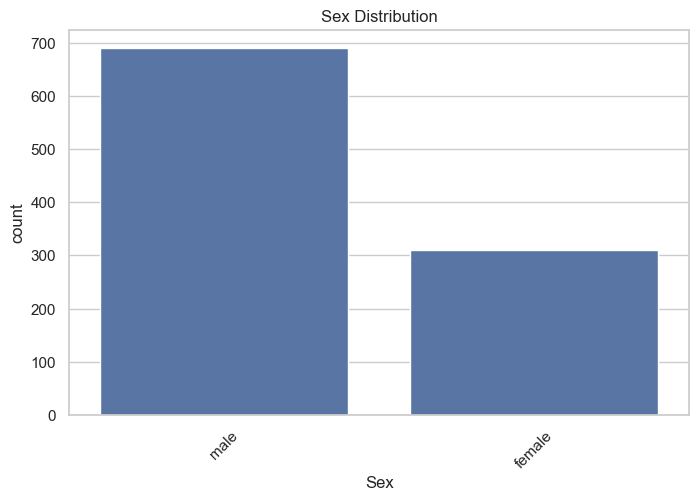

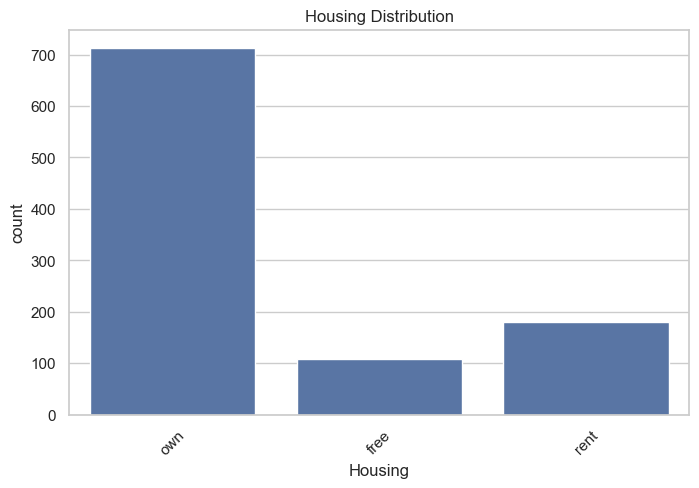

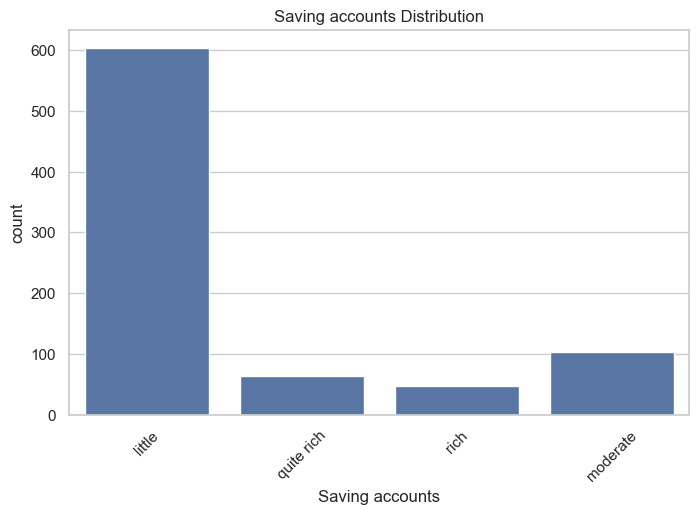

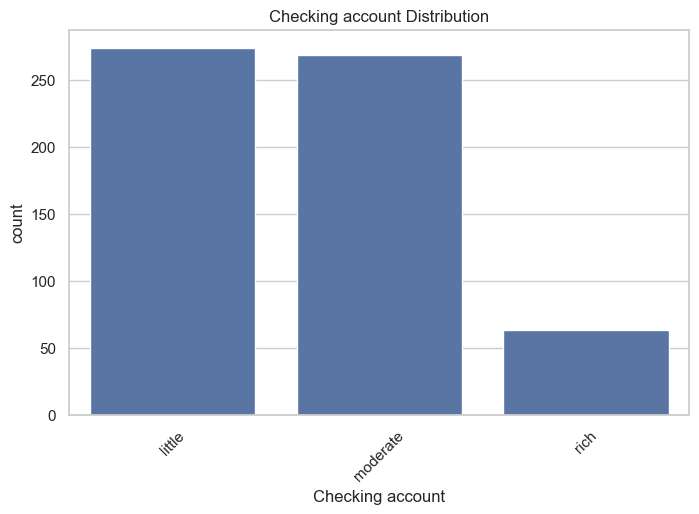

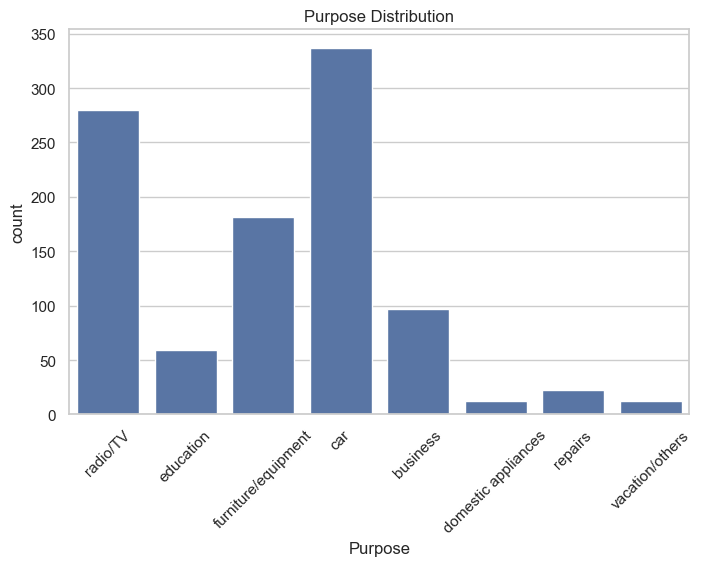

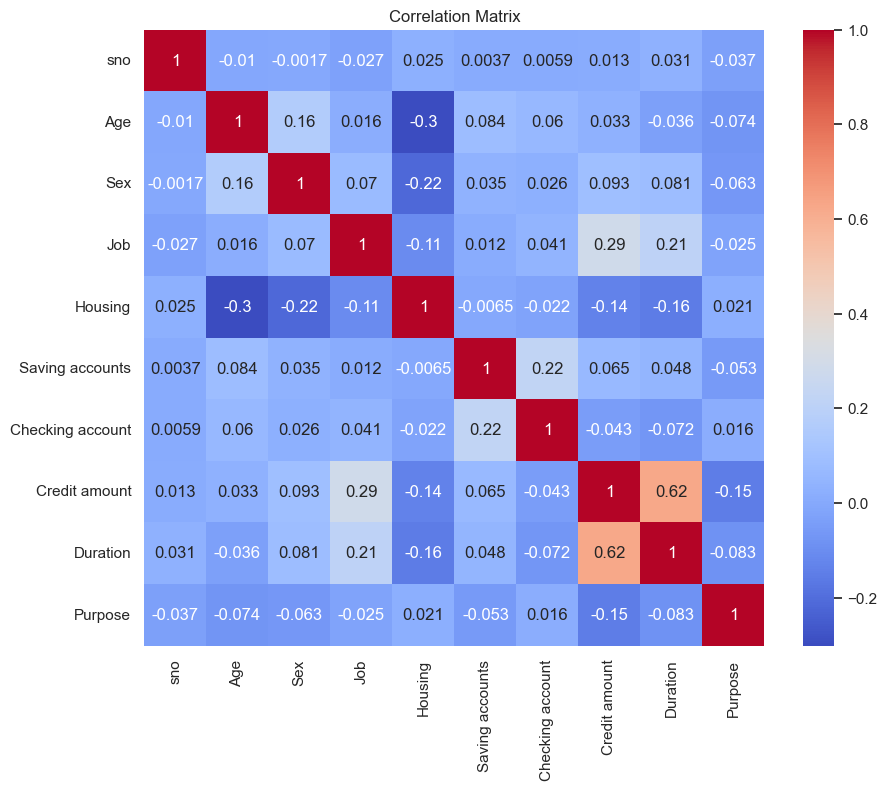

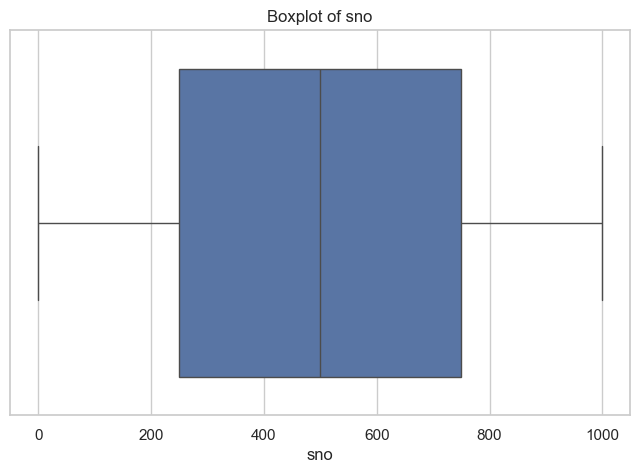

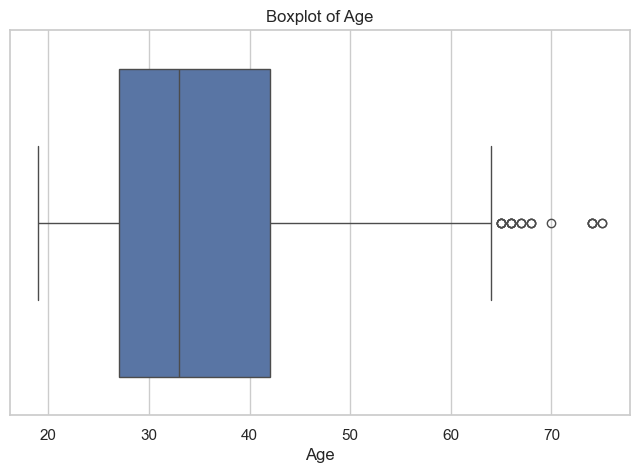

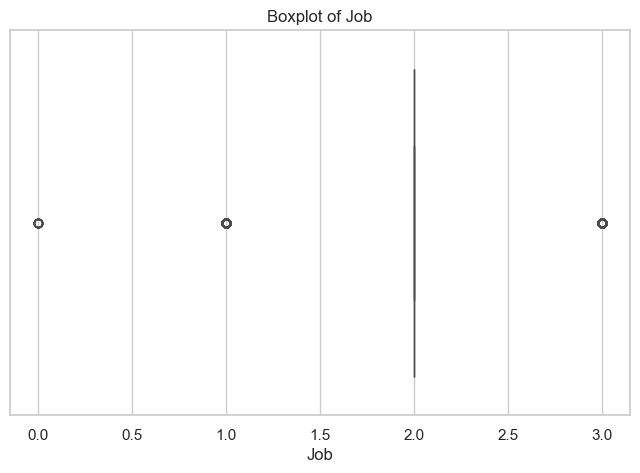

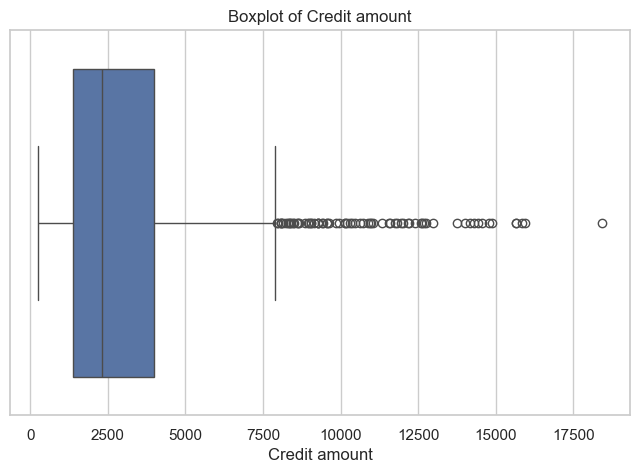

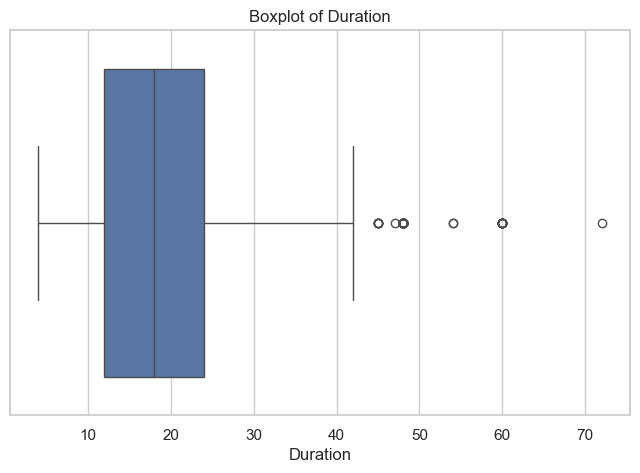


EDA Completed!

Observations:
- Checked missing values
- Analyzed numerical distributions (Age, Credit amount, Duration)
- Studied categorical features (Sex, Job, Housing, Purpose)
- Identified correlations
- Detected outliers



In [8]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("german_credit_data.csv")

print("Dataset Loaded!\n")

# ==============================
# 3. BASIC INFO
# ==============================
print(df.head())
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
print(df.info())

print("\nSummary:\n")
print(df.describe())

# Drop unnecessary column
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# ==============================
# 4. MISSING VALUES
# ==============================
print("\nMissing Values:\n")
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# ==============================
# 5. NUMERICAL FEATURES
# ==============================
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# ==============================
# 6. CATEGORICAL FEATURES
# ==============================
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

# ==============================
# 7. CORRELATION MATRIX
# ==============================
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 8. OUTLIER DETECTION
# ==============================
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ==============================
# 9. KEY INSIGHTS
# ==============================
print("\nEDA Completed!")

print("""
Observations:
- Checked missing values
- Analyzed numerical distributions (Age, Credit amount, Duration)
- Studied categorical features (Sex, Job, Housing, Purpose)
- Identified correlations
- Detected outliers
""")